<a href="https://colab.research.google.com/github/devangsharma230467-sys/ml2/blob/main/Copy_of_day4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4 – Deep Learning: CNNs and Further

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


## Vanishing Gradients

Classic problem with deep networks + sigmoid/tanh. Gradients get multiplied through layers and shrink to near-zero — early layers barely update.

**Fix:** ReLU activations, BatchNorm, residual connections (ResNet).

In [2]:
# quick demo of vanishing gradient with sigmoid
import torch

x = torch.tensor([2.0], requires_grad=True)
out = x
for _ in range(10):
    out = torch.sigmoid(out)

out.backward()
print(f'gradient after 10 sigmoid layers: {x.grad.item():.8f}')  # tiny

gradient after 10 sigmoid layers: 0.00000014


## CNN Model

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Hands-on: Image Classification on MNIST

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(len(train_dataset), len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.75MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.61MB/s]

60000 10000


In [5]:
# quick look at a batch
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)

torch.Size([64, 1, 28, 28]) torch.Size([64])


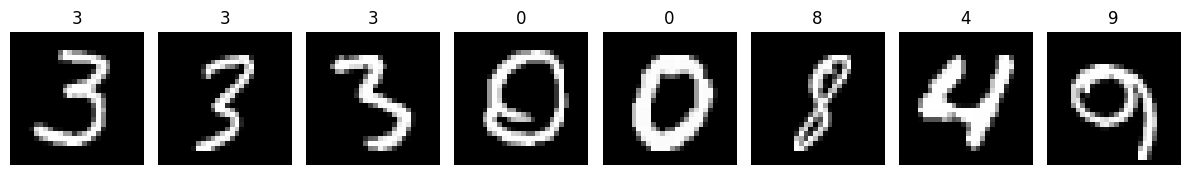

In [6]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    ax.set_title(labels[i].item())
    ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
        correct += (out.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def eval_epoch(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(1) == labels).sum().item()
    return correct / len(loader.dataset)

for epoch in range(3):
    loss, train_acc = train_epoch(model, train_loader)
    test_acc = eval_epoch(model, test_loader)
    print(f'Epoch {epoch+1} | loss: {loss:.3f} | train acc: {train_acc:.3f} | test acc: {test_acc:.3f}')

Epoch 1 | loss: 0.138 | train acc: 0.957 | test acc: 0.985
Epoch 2 | loss: 0.042 | train acc: 0.987 | test acc: 0.990
Epoch 3 | loss: 0.028 | train acc: 0.991 | test acc: 0.987


## Regularization: Dropout, EarlyStopping, BatchNorm

In [8]:
class RegularizedCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# early stopping — manual but simple
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best = None
        self.counter = 0

    def step(self, val_loss):
        if self.best is None or val_loss < self.best:
            self.best = val_loss
            self.counter = 0
            return False  # don't stop
        self.counter += 1
        return self.counter >= self.patience  # stop if True

In [ ]:
reg_model = RegularizedCNN().to(device)
optimizer2 = optim.Adam(reg_model.parameters(), lr=1e-3)
es = EarlyStopping(patience=2)

for epoch in range(5):
    loss, acc = train_epoch(reg_model, train_loader)
    print(f'Epoch {epoch+1} | loss: {loss:.4f} | acc: {acc:.3f}')
    if es.step(loss):
        print('Early stopping triggered')
        break

Epoch 1 | loss: 2.3655 | acc: 0.078
Epoch 2 | loss: 2.3638 | acc: 0.080
Epoch 3 | loss: 2.3637 | acc: 0.078


## VGG-16 (pretrained), ResNet, YOLO overview

VGG: very deep, only 3x3 convs, lots of parameters (~138M for VGG-16).  
ResNet: residual (skip) connections fix vanishing gradient. `output = F(x) + x`  
YOLO: single-pass object detection, predicts bboxes + class in one shot.

In [ ]:
from torchvision import models

vgg16 = models.vgg16(weights=None)  # weights='IMAGENET1K_V1' to load pretrained
resnet = models.resnet18(weights=None)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f'VGG-16 params:   {count_params(vgg16):,}')
print(f'ResNet-18 params: {count_params(resnet):,}')

In [ ]:
# ResNet skip connection — just to see how it works
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + x)  # skip connection

rb = ResidualBlock(32)
x_test = torch.randn(2, 32, 8, 8)
print(rb(x_test).shape)

## 3D-CNN

Same as 2D CNN but the kernel slides over (height, width, **depth/time**). Used for video classification.

In [ ]:
conv3d = nn.Conv3d(in_channels=1, out_channels=16, kernel_size=(3, 3, 3), padding=1)

# (batch, channels, depth, height, width)
video_clip = torch.randn(2, 1, 8, 32, 32)  # 2 clips, 8 frames, 32x32
out = conv3d(video_clip)
print(out.shape)  # should be (2, 16, 8, 32, 32)

## Autoencoders

Encoder compresses input to bottleneck → Decoder reconstructs. Trained with reconstruction loss (MSE usually). No labels needed.

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z).reshape(-1, 1, 28, 28)

ae = Autoencoder().to(device)
ae_optim = optim.Adam(ae.parameters(), lr=1e-3)
mse = nn.MSELoss()

for epoch in range(3):
    ae.train()
    total = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        recon = ae(imgs)
        loss = mse(recon, imgs)
        ae_optim.zero_grad()
        loss.backward()
        ae_optim.step()
        total += loss.item()
    print(f'Epoch {epoch+1} recon loss: {total/len(train_loader):.4f}')

In [ ]:
# visualise reconstructions
ae.eval()
sample_imgs, _ = next(iter(test_loader))
sample_imgs = sample_imgs[:8].to(device)
with torch.no_grad():
    recons = ae(sample_imgs).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(sample_imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recons[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Recon', fontsize=10)
plt.tight_layout()
plt.show()